In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
BASE = "/content/drive/MyDrive/Thesis/Analysis/Data/thesis"

In [ ]:
df_long = pd.read_csv(f"{BASE}/thesis_long_format.csv")
df_resp = pd.read_csv(f"{BASE}/thesis_respondent_level.csv")

In [ ]:
TRUST_ITEMS = [
    "p_trust1", "p_trust2", "p_trust3",
    "s_trust1", "s_trust2",
    "c_trust1", "c_trust2",
    "g_trust1",
]

##functions

In [ ]:
def compute_cronbach_alpha(df, items):
    """Compute Cronbach's alpha and item-total correlations."""
    item_data = df[items].dropna()
    n_items = len(items)
    if n_items < 2:
        return None, None

    item_vars = item_data.var(axis=0, ddof=1)
    total_var = item_data.sum(axis=1).var(ddof=1)
    alpha = (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var)

    totals = item_data.sum(axis=1)
    item_total_corr = {}
    for item in items:
        rest = totals - item_data[item]
        item_total_corr[item] = round(item_data[item].corr(rest), 3)

    return round(alpha, 3), item_total_corr

In [ ]:
def demographics_table(df_resp):
    """Print demographics summary table for Chapter 4."""
    n = len(df_resp)
    print(f"\n{'='*60}")
    print(f"TABLE 3: Sample Demographics (N = {n})")
    print(f"{'='*60}")

    # Gender
    gender_labels = {1: "Male", 2: "Female", 3: "Other", 4: "Prefer not to say"}
    g = df_resp["gender_cat"].map(gender_labels).value_counts()
    print("\nGender:")
    for label, count in g.items():
        print(f"  {label:<25} {count:>5}  ({count/n*100:.1f}%)")

    # Age
    age_labels = {1: "18-24", 2: "25-34", 3: "35-44", 4: "45-54", 5: "54+"}
    a = df_resp["age_cat"].map(age_labels).value_counts().sort_index()
    print("\nAge:")
    for label, count in a.items():
        print(f"  {label:<25} {count:>5}  ({count/n*100:.1f}%)")

    # Status
    status_labels = {1: "Student", 2: "Working", 3: "Other"}
    s = df_resp["status_cat"].map(status_labels).value_counts()
    print("\nStatus:")
    for label, count in s.items():
        print(f"  {label:<25} {count:>5}  ({count/n*100:.1f}%)")

    # Income
    income_labels = {
        0: "None", 1: "< NT$20,000", 2: "20,000-39,999",
        3: "40,000-59,999", 4: "60,000-79,999", 5: "80,000-99,999",
        6: "≥100,000", 7: "Prefer not to say",
    }
    i = df_resp["income_cat"].map(income_labels).value_counts()
    print("\nMonthly Income (NTD):")
    for label, count in i.items():
        print(f"  {label:<25} {count:>5}  ({count/n*100:.1f}%)")

    # Budget
    budget_labels = {
        1: "<1,000", 2: "1,000-2,999", 3: "3,000-4,999",
        4: "5,000-9,999", 5: "≥10,000", 6: "Prefer not to say",
    }
    b = df_resp["budget_cat"].map(budget_labels).value_counts()
    print("\nMonthly Clothing Budget (NTD):")
    for label, count in b.items():
        print(f"  {label:<25} {count:>5}  ({count/n*100:.1f}%)")


In [ ]:
def trust_risk_descriptives(df_resp):
    """Print trust index and risk aversion descriptives."""
    print(f"\n{'='*60}")
    print("TABLE 4: Trust Index and Risk Aversion Descriptives")
    print(f"{'='*60}")

    ti = df_resp["trust_index"]
    ra = df_resp["risk_aversion"]

    print(f"\n{'Variable':<20} {'Mean':>8} {'SD':>8} {'Min':>8} {'Max':>8}")
    print("-" * 55)
    print(f"{'Trust index':<20} {ti.mean():>8.2f} {ti.std():>8.2f} {ti.min():>8.2f} {ti.max():>8.2f}")
    print(f"{'Risk aversion':<20} {ra.mean():>8.2f} {ra.std():>8.2f} {ra.min():>8.0f} {ra.max():>8.0f}")

In [ ]:
def vignette_choice_rates(df_long):
    """Print online choice rates by experimental condition."""
    print(f"\n{'='*60}")
    print("TABLE 5: Online Choice Rates by Condition")
    print(f"{'='*60}")

    # By discount
    print("\nBy discount level:")
    d = df_long.groupby("discount")["online_choice"].agg(["mean", "count"])
    d.columns = ["Online %", "N"]
    d["Online %"] = (d["Online %"] * 100).round(1)
    print(d.to_string())

    # By reputation
    print("\nBy reputation:")
    r = df_long.groupby("reputation_high")["online_choice"].agg(["mean", "count"])
    r.index = ["Low", "High"]
    r.columns = ["Online %", "N"]
    r["Online %"] = (r["Online %"] * 100).round(1)
    print(r.to_string())

    # By price
    print("\nBy base price:")
    p = df_long.groupby("price_high")["online_choice"].agg(["mean", "count"])
    p.index = ["700 NTD", "1500 NTD"]
    p.columns = ["Online %", "N"]
    p["Online %"] = (p["Online %"] * 100).round(1)
    print(p.to_string())

    # Discount × Reputation (H2b)
    print("\nDiscount × Reputation (online %):")
    pivot = df_long.pivot_table(
        values="online_choice", index="discount",
        columns="reputation_high", aggfunc="mean",
    ).round(3) * 100
    pivot.columns = ["Low Rep", "High Rep"]
    print(pivot.to_string())

    # Discount × Price (H1c)
    print("\nDiscount × Price (online %):")
    pivot2 = df_long.pivot_table(
        values="online_choice", index="discount",
        columns="price_high", aggfunc="mean",
    ).round(3) * 100
    pivot2.columns = ["700 NTD", "1500 NTD"]
    print(pivot2.to_string())

    # Overall
    overall = df_long["online_choice"].mean() * 100
    print(f"\nOverall online choice rate: {overall:.1f}%")

In [ ]:
def plot_discount_main(df_long):
    """Figure 2: Online choice rate by discount level."""
    fig, ax = plt.subplots(figsize=(8, 5))
    rates = df_long.groupby("discount")["online_choice"].mean() * 100
    rates.plot(kind="bar", ax=ax, color="#5B9BD5", edgecolor="white")
    ax.set_xlabel("Discount Level (%)")
    ax.set_ylabel("Online Choice Rate (%)")
    ax.set_title("Online Choice Rate by Discount Level")
    ax.set_xticklabels([f"{d}%" for d in rates.index], rotation=0)
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.savefig(f"{BASE}/fig2_discount_main.png", dpi=150)
    plt.show()
    print("Saved: fig2_discount_main.png")

In [ ]:
def plot_discount_x_reputation(df_long):
    """Figure 3: Online choice rate by discount × reputation (H2b)."""
    fig, ax = plt.subplots(figsize=(8, 5))
    pivot = df_long.pivot_table(
        values="online_choice", index="discount",
        columns="reputation_high", aggfunc="mean",
    ) * 100
    pivot.columns = ["Low Reputation", "High Reputation"]
    pivot.plot(kind="bar", ax=ax, color=["#E07B54", "#5B9BD5"], edgecolor="white")
    ax.set_xlabel("Discount Level (%)")
    ax.set_ylabel("Online Choice Rate (%)")
    ax.set_title("Online Choice Rate by Discount Level and Seller Reputation")
    ax.set_xticklabels([f"{d}%" for d in pivot.index], rotation=0)
    ax.set_ylim(0, 100)
    ax.legend(title="Seller Reputation")
    plt.tight_layout()
    plt.savefig(f"{BASE}/fig3_discount_x_reputation.png", dpi=150)
    plt.show()
    print("Saved: fig3_discount_x_reputation.png")

In [ ]:
def plot_discount_x_price(df_long):
    """Figure 4: Online choice rate by discount × base price (H1c)."""
    fig, ax = plt.subplots(figsize=(8, 5))
    pivot = df_long.pivot_table(
        values="online_choice", index="discount",
        columns="price_high", aggfunc="mean",
    ) * 100
    pivot.columns = ["700 NTD", "1,500 NTD"]
    pivot.plot(kind="bar", ax=ax, color=["#70AD47", "#7030A0"], edgecolor="white")
    ax.set_xlabel("Discount Level (%)")
    ax.set_ylabel("Online Choice Rate (%)")
    ax.set_title("Online Choice Rate by Discount Level and Base Price")
    ax.set_xticklabels([f"{d}%" for d in pivot.index], rotation=0)
    ax.set_ylim(0, 100)
    ax.legend(title="Base Price")
    plt.tight_layout()
    plt.savefig(f"{BASE}/fig4_discount_x_price.png", dpi=150)
    plt.show()
    print("Saved: fig4_discount_x_price.png")

In [ ]:
def plot_trust_distribution(df_resp):
    """Figure 5: Trust index distribution."""
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df_resp["trust_index"], bins=15, color="#5B9BD5", edgecolor="white")
    ax.set_xlabel("Trust Index Score")
    ax.set_ylabel("Frequency")
    ax.set_title("Distribution of Trust Index Scores")
    ax.axvline(df_resp["trust_index"].mean(), color="red", linestyle="--",
               label=f"Mean = {df_resp['trust_index'].mean():.2f}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{BASE}/fig5_trust_distribution.png", dpi=150)
    plt.show()
    print("Saved: fig5_trust_distribution.png")

In [ ]:
def plot_status_bivariate(df_long):
    """Figure 6: Trait and channel-choice distributions by occupational status."""
    lab = {1: "Student", 2: "Working", 3: "Other"}
    person = df_long.groupby("survey_id").agg(
        status=("status_cat", "first"),
        trust=("trust_index", "first"),
        risk=("risk_aversion", "first"),
        online_rate=("online_choice", "mean"),
    ).reset_index()
    person["grp"] = person["status"].map(lab)
    pw = person[person["grp"].isin(["Student", "Working"])]

    BLUE, ORANGE = "#5B9BD5", "#E07B54"
    panels = [("trust", "Trust Index Score", (1, 7)),
              ("risk", "Risk Aversion Score", (1, 7)),
              ("online_rate", "Online-Choice Rate", (0, 1))]

    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    for ax, (col, ylab, ylim) in zip(axes, panels):
        data = [pw[pw.grp == "Student"][col].values,
                pw[pw.grp == "Working"][col].values]
        bp = ax.boxplot(data, tick_labels=["Student", "Working"],
                        patch_artist=True, widths=0.55,
                        medianprops=dict(color="black", linewidth=1.5),
                        flierprops=dict(marker="o", markersize=3,
                                        markerfacecolor="gray",
                                        markeredgecolor="gray", alpha=0.5))
        for patch, c in zip(bp["boxes"], [BLUE, ORANGE]):
            patch.set_facecolor(c); patch.set_edgecolor("white"); patch.set_alpha(0.9)
        for i, d in enumerate(data, start=1):
            x = np.random.normal(i, 0.06, size=len(d))
            ax.scatter(x, d, s=10, color="dimgray", alpha=0.35, zorder=3)
        ax.set_ylabel(ylab); ax.set_ylim(ylim)
        ax.set_title(ylab.split(" (")[0])
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    fig.suptitle("Trait and Channel-Choice Distributions by Occupational Status",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{BASE}/fig6_status_bivariate.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig6_status_bivariate.png")

##analysis

In [ ]:
alpha, item_total = compute_cronbach_alpha(df_resp, TRUST_ITEMS)
print(f"Cronbach's alpha: {alpha}")
print("\nItem-total correlations:")
for item, corr in item_total.items():
    print(f"  {item}: {corr}")

Cronbach's alpha: 0.808

Item-total correlations:
  p_trust1: 0.589
  p_trust2: 0.352
  p_trust3: 0.583
  s_trust1: 0.645
  s_trust2: 0.417
  c_trust1: 0.62
  c_trust2: 0.567
  g_trust1: 0.467


In [ ]:
low_items = [item for item, corr in item_total.items() if corr < 0.3]
if low_items:
    print(f"\n⚠ Low item-total correlations: {low_items}")
    print("  Consider dropping these and recomputing alpha.")
    print("  To drop: update TRUST_ITEMS_FINAL below and re-run.")
else:
    print("\n✓ All item-total correlations acceptable (≥ 0.3)")


✓ All item-total correlations acceptable (≥ 0.3)


In [ ]:
TRUST_ITEMS_FINAL = TRUST_ITEMS.copy()

In [ ]:
print(f"\nComputing trust index from {len(TRUST_ITEMS_FINAL)} items...")
df_resp["trust_index"] = df_resp[TRUST_ITEMS_FINAL].mean(axis=1).round(3)
df_long["trust_index"] = df_long["survey_id"].map(
    df_resp.set_index("survey_id")["trust_index"]
)
print(f"Trust index: mean={df_resp['trust_index'].mean():.2f}, SD={df_resp['trust_index'].std():.2f}")


Computing trust index from 8 items...
Trust index: mean=4.61, SD=0.82


In [ ]:
df_long.to_csv(f"{BASE}/thesis_long_format.csv", index=False)
df_resp.to_csv(f"{BASE}/thesis_respondent_level.csv", index=False)
print("Updated CSVs exported with trust_index column.")

Updated CSVs exported with trust_index column.


##Tables

In [ ]:
demographics_table(df_resp)
trust_risk_descriptives(df_resp)
vignette_choice_rates(df_long)


TABLE 3: Sample Demographics (N = 121)

Gender:
  Female                       68  (56.2%)
  Male                         53  (43.8%)

Age:
  18-24                        63  (52.1%)
  25-34                        40  (33.1%)
  35-44                        17  (14.0%)
  45-54                         1  (0.8%)

Status:
  Student                      69  (57.0%)
  Working                      47  (38.8%)
  Other                         5  (4.1%)

Monthly Income (NTD):
  < NT$20,000                  39  (32.2%)
  40,000-59,999                24  (19.8%)
  None                         21  (17.4%)
  20,000-39,999                12  (9.9%)
  60,000-79,999                11  (9.1%)
  ≥100,000                      6  (5.0%)
  Prefer not to say             5  (4.1%)
  80,000-99,999                 3  (2.5%)

Monthly Clothing Budget (NTD):
  1,000-2,999                  50  (41.3%)
  <1,000                       42  (34.7%)
  3,000-4,999                  14  (11.6%)
  5,000-9,999               

#Graphs

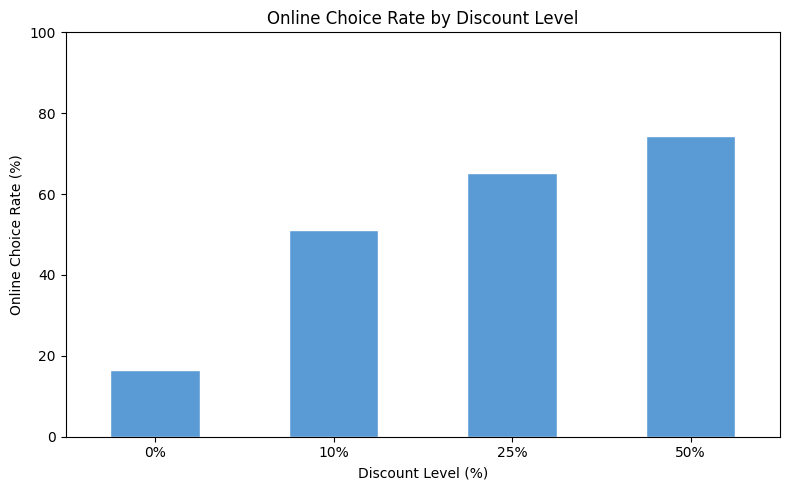

Saved: fig2_discount_main.png


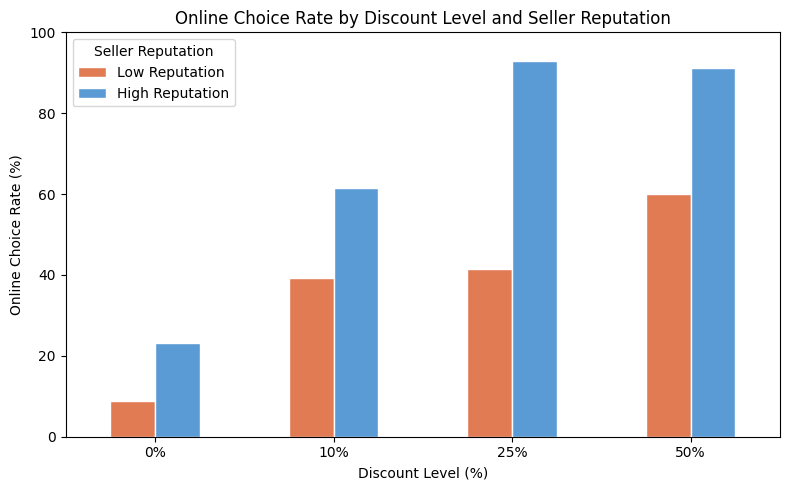

Saved: fig3_discount_x_reputation.png


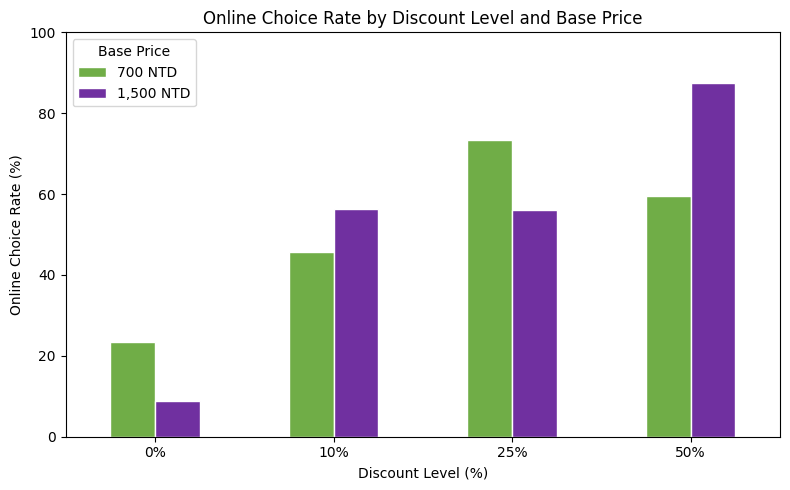

Saved: fig4_discount_x_price.png


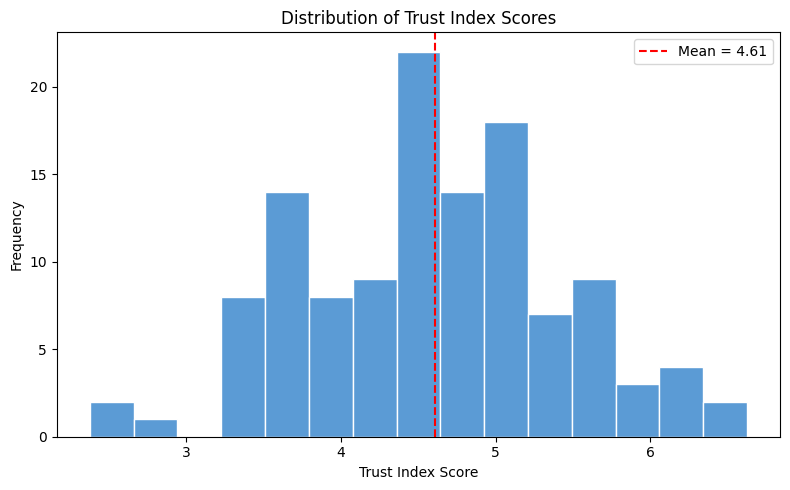

Saved: fig5_trust_distribution.png


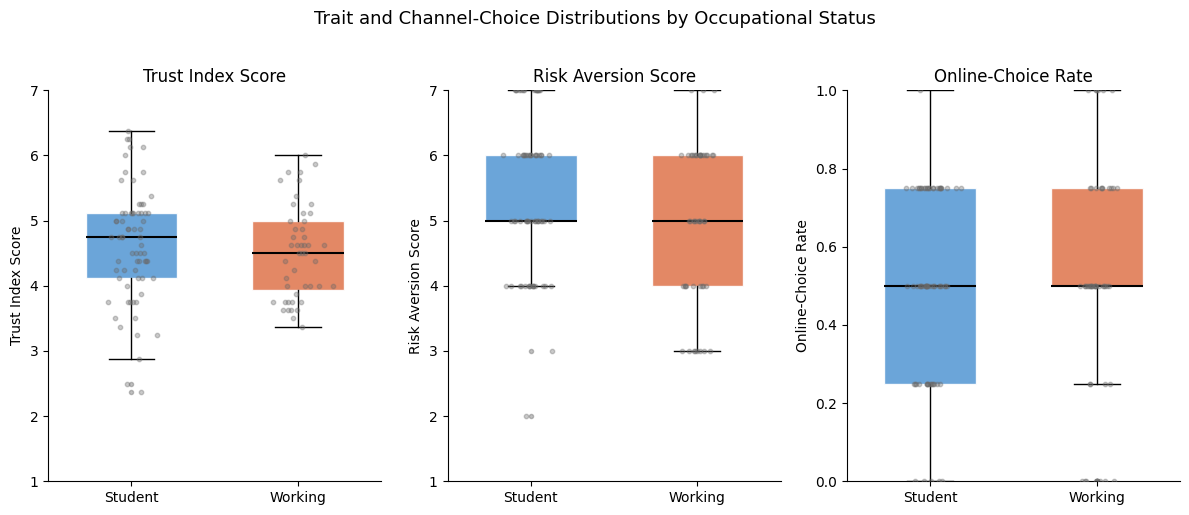

Saved: fig6_status_bivariate.png


In [ ]:
plot_discount_main(df_long)
plot_discount_x_reputation(df_long)
plot_discount_x_price(df_long)
plot_trust_distribution(df_resp)
plot_status_bivariate(df_long)